In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [14]:
fred_md = pd.read_csv("./datasets/FRED_MD_2026_05.csv")

# Keep transformation row before converting dates
transforms = fred_md.loc[fred_md["sasdate"] == "Transform:"].iloc[0].drop("sasdate")
transforms = transforms.astype(int).to_dict()

fred_md = fred_md[fred_md["sasdate"] != "Transform:"].copy()
fred_md["sasdate"] = pd.to_datetime(fred_md["sasdate"], format="%m/%d/%Y")
fred_md = fred_md.set_index("sasdate")
fred_md = fred_md.apply(pd.to_numeric, errors="coerce")
fred_md = fred_md.sort_index()
fred_md = fred_md.loc["1963-6-01":"2026-04-01"]

fred_md.head()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1963-06-01,3058.664,2861.0,17.881,304332.5361,20542.37530,27.0622,28.9373,27.7977,39.3274,26.1278,...,18.915,11.126,2.46,2.98,2.34,NaN,7984.0,18236.0,90.0224,12.0403
1963-07-01,3060.387,2862.7,17.973,312852.1672,20780.80730,26.9545,28.9373,27.7977,39.2095,26.1019,...,18.993,11.139,2.47,2.99,2.35,NaN,8110.0,18497.0,90.2269,14.2966
1963-08-01,3071.095,2872.9,18.037,310735.2354,20754.65020,27.0083,29.1983,28.1047,39.5238,26.1537,...,19.040,11.150,2.47,3.01,2.34,96.4,8185.0,18750.0,88.9845,11.4839
1963-09-01,3091.894,2893.0,18.003,307838.1396,20703.34205,27.2776,29.2853,28.1884,39.6417,26.6203,...,18.954,11.164,2.48,3.01,2.36,NaN,8123.0,18867.0,89.5672,13.0301
1963-10-01,3109.050,2908.9,17.993,316321.4105,21063.50515,27.4661,29.5462,28.3838,39.9167,26.6462,...,18.989,11.193,2.48,3.02,2.36,NaN,8179.0,19064.0,90.1585,13.8203


Selecting a subset of the FRED-MD database to avoid lots of overlapping fields

In [15]:
selected_cols = [
    # (i) Output and activity
    "RPI",
    "W875RX1",
    "DPCERA3M086SBEA",
    "RETAILx",
    "INDPRO",
    "IPMANSICS",
    "CUMFNS",

    # (ii) Employment
    "UNRATE",
    "UEMPMEAN",
    "CLAIMSx",
    "PAYEMS",
    "MANEMP",
    "SRVPRD",
    "AWHMAN",

    # (iii) Inflation
    "CPIAUCSL",
    "CPIULFSL",
    "PCEPI",
    "WPSFD49207",
    "WPSID61",
    "OILPRICEx",

    # (iv) Interest rates and term spreads
    "HOUST",
    "FEDFUNDS",
    "GS1",
    "GS10",
    "T10YFFM",

    # (v) Credit spreads
    "AAA",
    "BAA",
    "AAAFFM",
    "BAAFFM",

    # (vi) Money and liquidity
    "M2SL",
    "BOGMBASE",
    "BUSLOANS",

    # (vii) Financial market stress proxies
    "S&P 500",
    "S&P PE ratio",
    "VIXCLSx",
]

Check for missing values in the selected columns

In [16]:
# Find columns with missing values
nans = []
for col in selected_cols:
    if not (col in fred_md.dropna(axis=1).columns):
        nans.append(col)

print(f"There are {len(nans)} columns with missing values: {', '.join(nans)}")

There are 4 columns with missing values: UNRATE, UEMPMEAN, CPIAUCSL, CPIULFSL


How many missing values are there from each of these?

In [18]:
fred_md[nans].isna().sum()

UNRATE      1
UEMPMEAN    1
CPIAUCSL    1
CPIULFSL    1
dtype: int64

These missing values all apear for the month of October 2025, like I saw in the previous notebook. There is only 1 missing date, which I assume we can fill with linear interpolation. Or with some sort of clever graph method? 

In [19]:
fred_md_selected = fred_md[selected_cols]

# 1. Initialize a list to hold the row data
summary_data = []

# 2. Helper function to calculate the longest flatline period
def get_max_flatline(series):
    # If the series has fewer than 2 elements, flatline is 0
    if len(series) < 2:
        return 0
    return (series.diff() == 0).astype(int).groupby((series.diff() != 0).cumsum()).sum().max()

# 3. Gather metrics for each column in df
for col in fred_md_selected.columns:
    summary_data.append({
        "Column Name": col,
        "Start": fred_md_selected[col].first_valid_index(),
        "End": fred_md_selected[col].last_valid_index(),
        "N Null": fred_md_selected[col].isna().sum(),
        "N Not-Null": fred_md_selected[col].notnull().sum(),
        "N Unique": fred_md_selected[col].nunique(),
        "Max Flatline": get_max_flatline(fred_md_selected[col])
    })


# 5. Convert to a DataFrame and display without the row index numbers
summary_df = pd.DataFrame(summary_data)
summary_df


,Column Name,Start,End,N Null,N Not-Null,N Unique,Max Flatline
0,RPI,1963-06-01,2026-04-01,0,755,755,0
1,W875RX1,1963-06-01,2026-04-01,0,755,755,0
2,DPCERA3M086SBEA,1963-06-01,2026-04-01,0,755,752,0
3,RETAILx,1963-06-01,2026-04-01,0,755,753,1
4,INDPRO,1963-06-01,2026-04-01,0,755,753,1
5,IPMANSICS,1963-06-01,2026-04-01,0,755,753,1
6,CUMFNS,1963-06-01,2026-04-01,0,755,754,0
7,UNRATE,1963-06-01,2026-04-01,1,754,74,8
8,UEMPMEAN,1963-06-01,2026-04-01,1,754,239,3
9,CLAIMSx,1963-06-01,2026-04-01,0,755,651,1


- **N Null**: 448 missing datapoints for quarterly data is expected. There is however one missing datapoint for `UNRATE`, `UEMPMEAN`, `CPIAUCSL`, and `CPIULFSL`. I imagine that we can linearly interpolate for this small discrepency, or find new data. I think that it is justifiable to interpolate here.
- **N Not-Null vs. N Unique**: The repeats seem to be due to rounding. The `UNRATE` looked suspicious, but the values are provided to one decimal-place and the mean is 6.1 with a standard deviation of 1.7. Similary, `AWHMAN` is the average weekly hours of production which is set by factories and unions etc. There is a mean of 40.8 and a standard deviation of 0.7, so with only one decimal place, I think that not many unique values is reasonable.
- **Max Flatline** (longest stretch of the same value): I am suspicious of `UNRATE`, `AWHMAN`, `OILPRICEx`, and `FEDFUNDS`.
    - `UNRATE`: At the height of the dot-com bubble, US unemployment remained steadily low ([1]. I suspect they are using the same data as FRED anyway, but google seems to agree that this was a steady time)
    - `AWHMAN`: I see no reason that the average weekly hours of production can't remain stationary for 9 months. I have checked another dataset [5] which reports the same dataset but for private companies and they report a $\pm 0.1$ deviation throughout this period.
    - `OILPRICEx`:  In the 70s oil prices were set by the oil companies called "posted prices", rather than being set by the free-market [3], so the prices were extremely stable. The spot price of oil only didn't exist on the free market until 1983. The posted prices were not what was actually charged, so this seems like a bit of a poor indicator. There is a monthly consumer price index for fuel oil and other fuels in the US which goes back to 1970 [4], but I am not sure if this is a replacement for pure oil price.
    - `FEDFUNDS`: Fed funds rate remained unchanged from August 2023-2024 so this looks fine [2]


1. https://www.macrotrends.net/1316/us-national-unemployment-rate
2. https://www.gam.com/en/our-thinking/multi-asset-blog/fed-leaves-interest-rates-unchanged-as-expected-august-2024
3. https://blogs.worldbank.org/en/developmenttalk/how-do-current-oil-market-conditions-differ-those-during-price-shocks-1970s
4. https://fred.stlouisfed.org/series/CUSR0000SEHE
5. https://fred.stlouisfed.org/data/AWHNONAG

### Plotting each of the time series

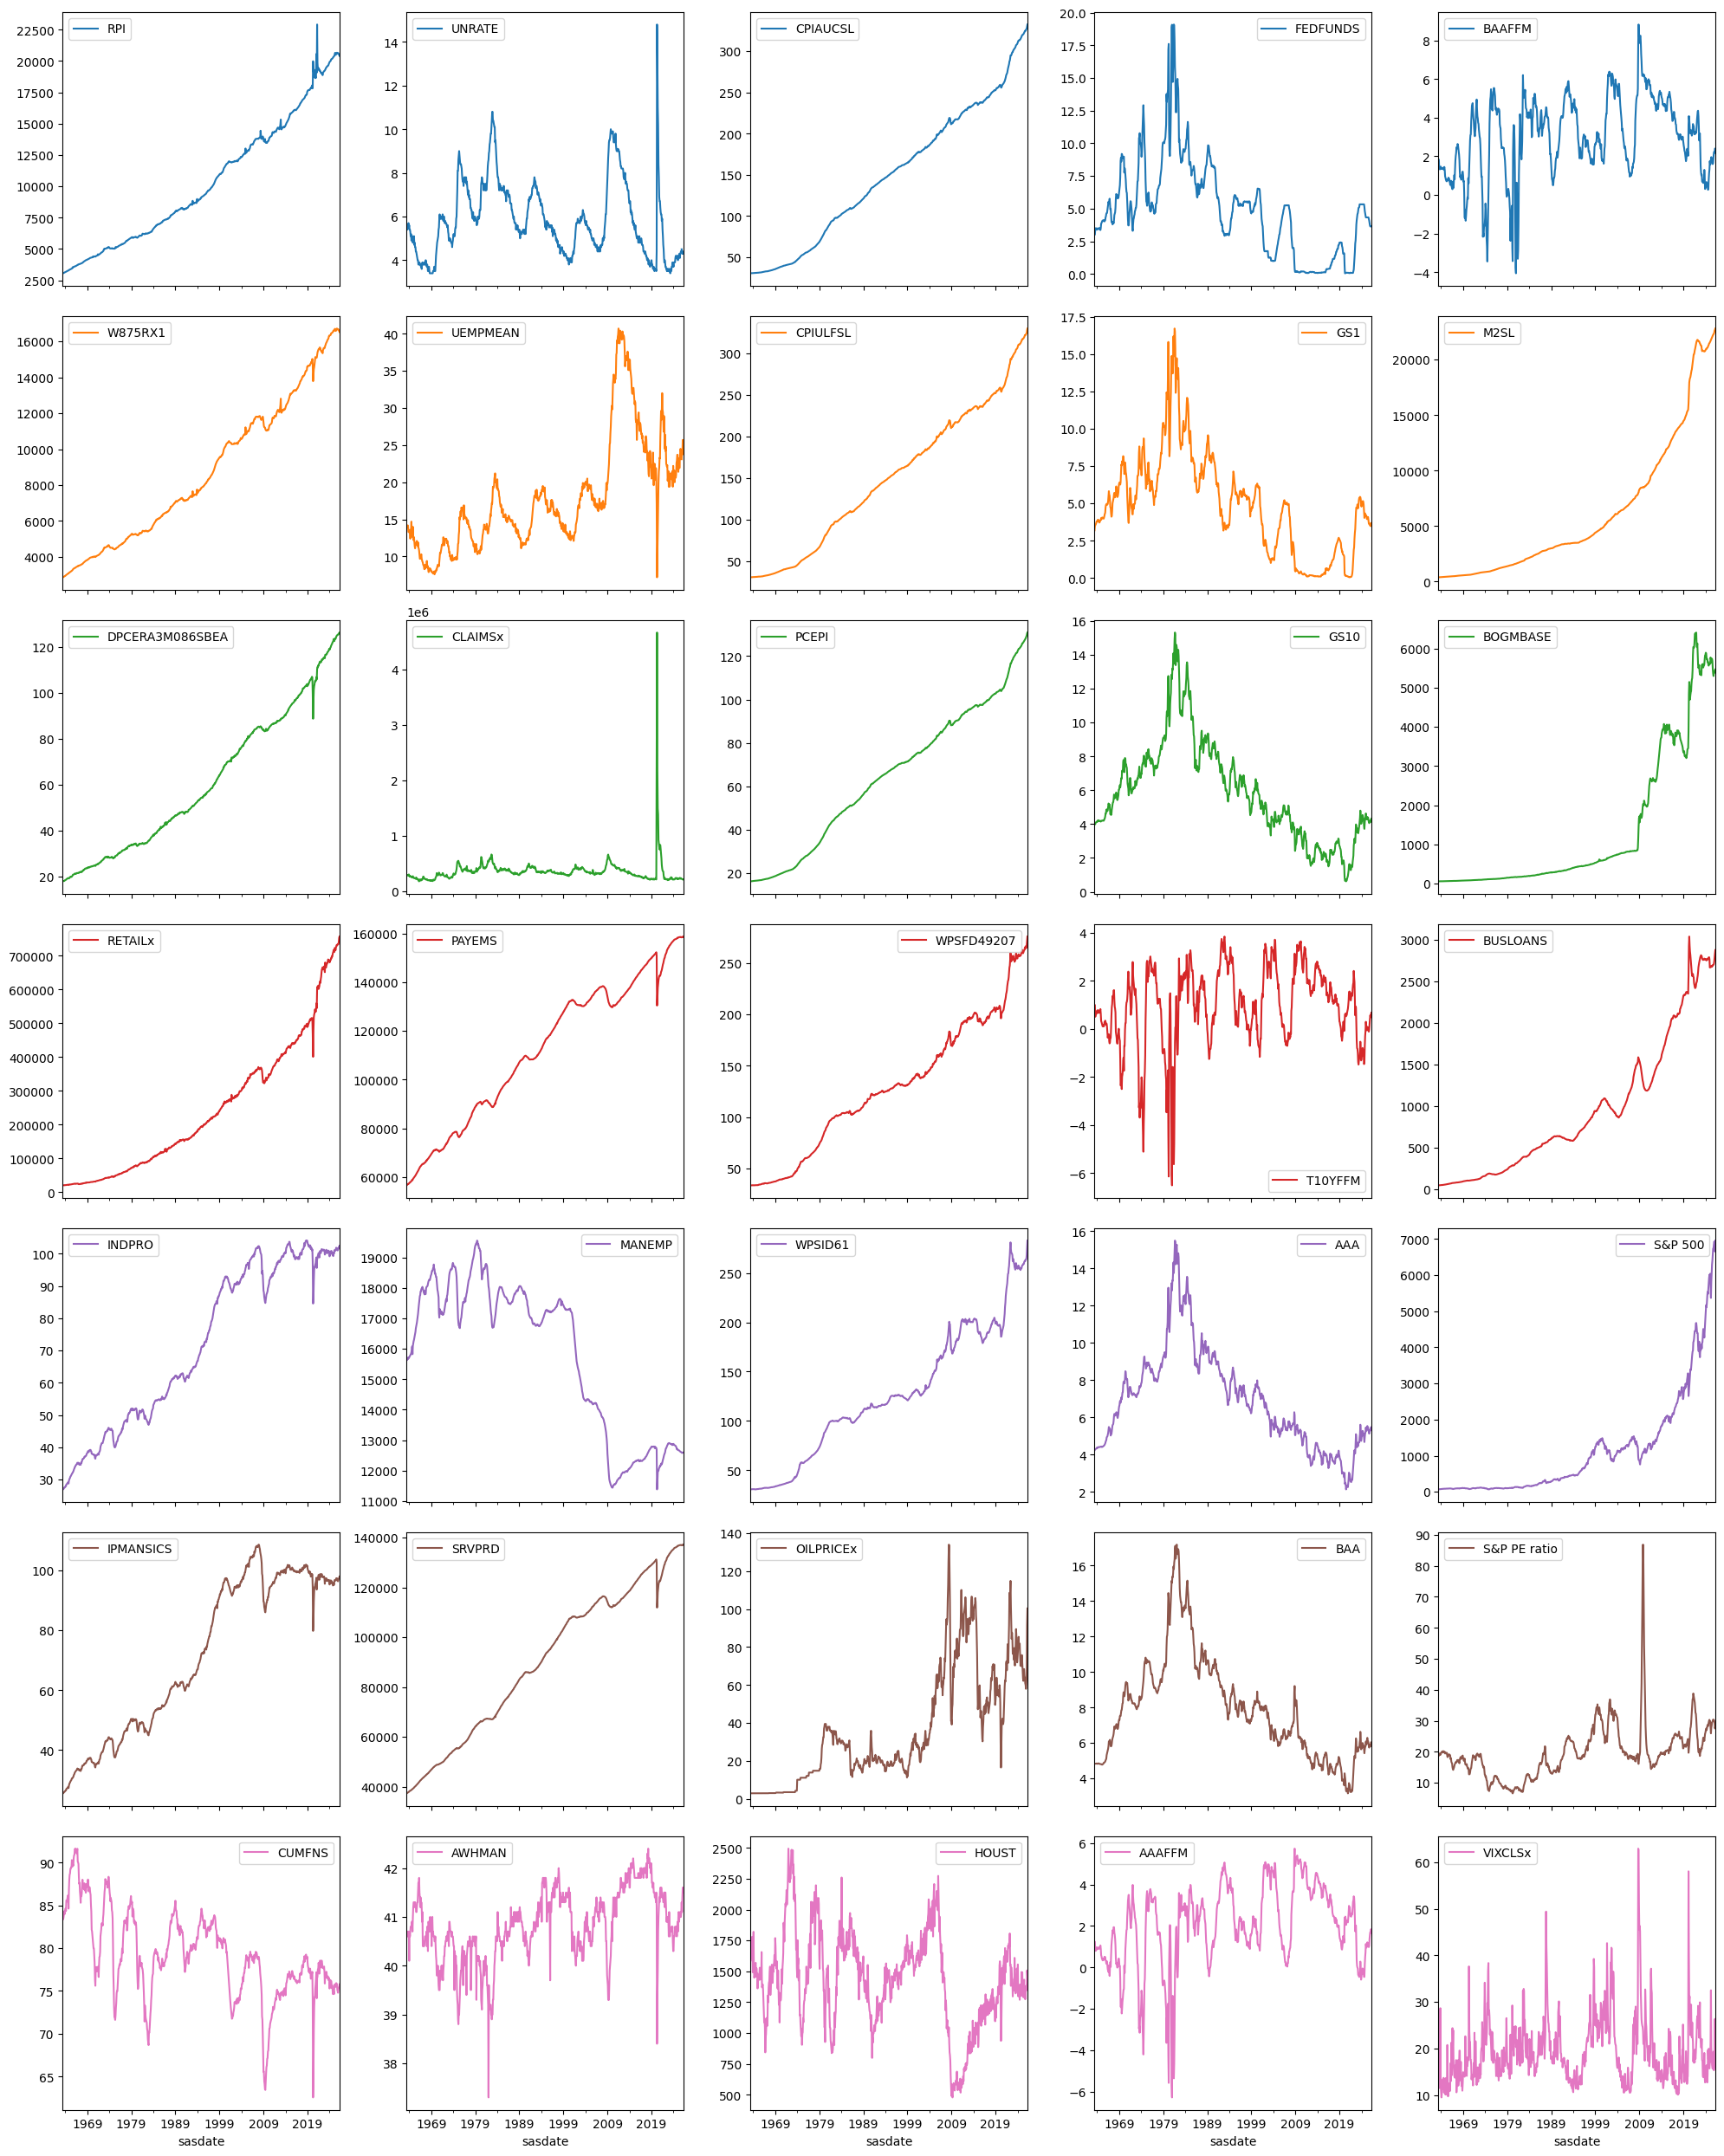

In [20]:
# 17 rows of plots, 2 columns side-by-side
num_rows = 7 
fig, axes = plt.subplots(num_rows, 5, figsize=(20, 25), sharex=True)

# Flatten the axes array into 1D arrays for each column
col1_axes = axes[:, 0]
col2_axes = axes[:, 1]
col3_axes = axes[:, 2]
col4_axes = axes[:, 3]
col5_axes = axes[:, 4]

# Plot first 17 columns in the left column
fred_md_selected[selected_cols[:7]].plot(subplots=True, ax=col1_axes[:7])

# Plot remaining columns in the right column
fred_md_selected[selected_cols[7:14]].plot(subplots=True, ax=col2_axes[:len(selected_cols[7:14])])
fred_md_selected[selected_cols[14:21]].plot(subplots=True, ax=col3_axes[:len(selected_cols[14:21])])
fred_md_selected[selected_cols[21:28]].plot(subplots=True, ax=col4_axes[:len(selected_cols[21:28])])
fred_md_selected[selected_cols[28:]].plot(subplots=True, ax=col5_axes[:len(selected_cols[28:])])

# Turn off any unused empty subplots in the grid
for ax in axes.flat:
    if not ax.has_data():
        ax.set_visible(False)

plt.tight_layout()
plt.show()


This seems to be quite a good spread of variables. Lots are quite similar so maybe we can remove later on if it is suitable.

Importantly, there seems to be no missing data, it all looks good.

### Transforming the variables

The column tcode denotes the following data transformation for a series $x$: (1) no transformation; (2) $\Delta x_t$; (3) $\Delta^2 x_t$; (4) $\log(x_t)$; (5) $\Delta \log(x_t)$; (6) $\Delta^2 \log(x_t)$; (7) $\Delta (x_t/x_{t−1} − 1.0)$.

Before doing this, I needed to address the missing values in October 2025, this is because any transform involving a difference returns NaN around the missing values. I also extended the dataset to start 2 months before 1970 so that the transformed data starts on the first month of 1970.

In [21]:
fred_md_selected[nans].loc["8/1/2025":"12/1/2025"]

,UNRATE,UEMPMEAN,CPIAUCSL,CPIULFSL
sasdate,,,,
2025-08-01,4.3,24.5,323.291,320.497
2025-09-01,4.4,24.1,324.245,321.478
2025-10-01,NaN,NaN,NaN,NaN
2025-11-01,4.5,23.1,325.063,322.372
2025-12-01,4.4,24.4,326.031,323.150


In [22]:
fred_md_selected = fred_md_selected.interpolate(method="linear")
fred_md_selected[nans].loc["8/1/2025":"12/1/2025"]

,UNRATE,UEMPMEAN,CPIAUCSL,CPIULFSL
sasdate,,,,
2025-08-01,4.30,24.5,323.291,320.497
2025-09-01,4.40,24.1,324.245,321.478
2025-10-01,4.45,23.6,324.654,321.925
2025-11-01,4.50,23.1,325.063,322.372
2025-12-01,4.40,24.4,326.031,323.150


In [23]:
def transform_series(x, tcode):
    x = x.astype(float)
    if tcode == 1: return x
    elif tcode == 2: return x.diff()
    elif tcode == 3: return x.diff().diff()
    elif tcode == 4: return np.log(x)
    elif tcode == 5: return np.log(x).diff()
    elif tcode == 6: return np.log(x).diff().diff()
    elif tcode == 7: return x.pct_change().diff()
    else: raise ValueError(f"Unknown transformation code: {tcode}")

fred_md_transformed = pd.DataFrame(index=fred_md_selected.index)

for col in fred_md_selected.columns:
    fred_md_transformed[col] = transform_series(
        fred_md_selected[col],
        transforms[col]
    )

fred_md_transformed = fred_md_transformed.replace([np.inf, -np.inf], np.nan)
fred_md_transformed = fred_md_transformed.dropna()

### Standardising the dataframe so that $\tilde z^j_t =\frac{z^j_t − \bar z^j}{s^j}$ , $j = 1,\ldots , D$

In [24]:
final_df = (fred_md_transformed - fred_md_transformed.mean()) / fred_md_transformed.std()

dates = final_df.index
variable_names = final_df.columns

X = final_df.to_numpy()
X.shape

np.save("./datasets/X.npy", X)

# Phase 1 outputs

### Final Clean Matrix

$\tilde X \in \mathbb{R}^{753 \times 35}$

### Data Audit Table

| Item                                 | Value                                                                                                                                                                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Dataset Name**                     | FRED-MD (Federal Reserve Economic Data - Monthly Database)                                                                                                                                                                     |
| **Sample Period**                    | 1963-08-01 to 2026-04-01                                                                                                                                                                                                       |
| **Number of Observations (N)**       | 753 monthly observations                                                                                                                                                                                                       |
| **Raw Dimension ((D_{\text{raw}}))** | 126 variables                                                                                                                                                                                                                  |
| **Final Dimension ((D))**            | 35 variables                                                                                                                                                                                                                   |
| **Transformation Rules**             | FRED-MD transformation codes: (1) $(x_t)$; (2) $(\Delta x_t)$; (3) $(\Delta^2 x_t)$; (4) $(\log(x_t))$; (5) $(\Delta \log(x_t))$; (6) $(\Delta^2 \log(x_t))$; (7) $(\Delta(x_t/x_{t-1}-1))$                                                  |
| **Missing Data Treatment**           | Four isolated missing observations were identified across four variables. These represented less than 0.02% of the dataset and were imputed using linear interpolation. No other missing values were present after processing. |
| **Variables Retained**               | 35 variables selected to represent output and activity, labour markets, housing, inflation, interest rates, credit conditions, money and liquidity, and financial market stress.                                               |
| **Variables Removed**                | 91 variables removed due to redundancy, high collinearity, excessive sectoral disaggregation, or overlap with retained indicators. Full list reported in Appendix X.                                                           |

### Plots

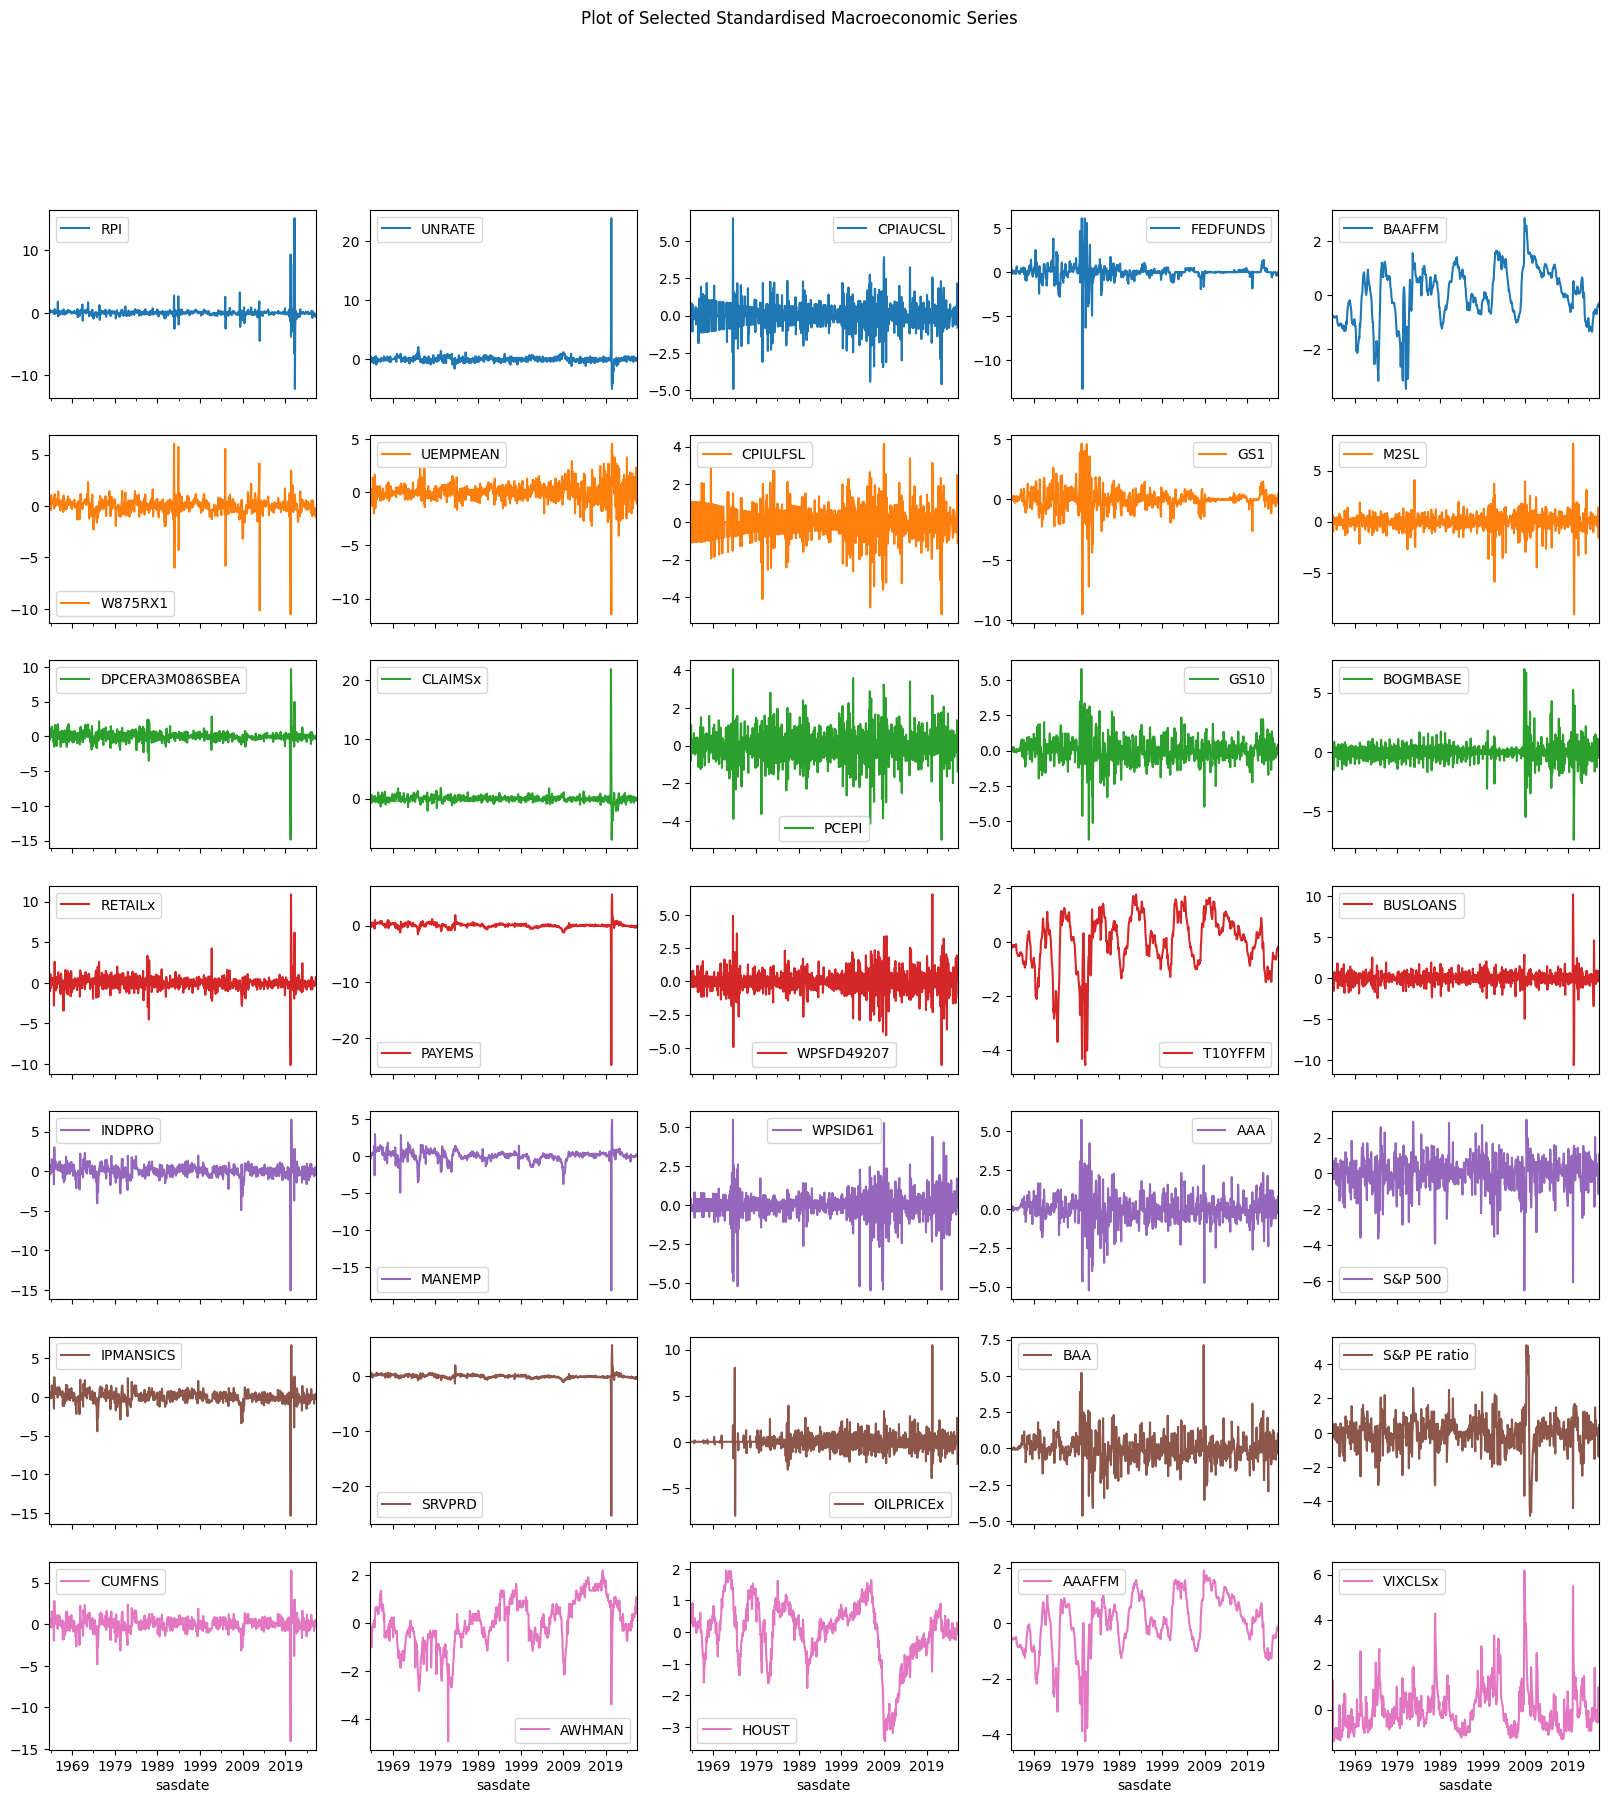

In [25]:
# 17 rows of plots, 2 columns side-by-side
num_rows = 7 
fig, axes = plt.subplots(num_rows, 5, figsize=(20, 20), sharex=True)

fig.suptitle("Plot of Selected Standardised Macroeconomic Series")

# Flatten the axes array into 1D arrays for each column
col1_axes = axes[:, 0]
col2_axes = axes[:, 1]
col3_axes = axes[:, 2]
col4_axes = axes[:, 3]
col5_axes = axes[:, 4]

# Plot first 17 columns in the left column
final_df[selected_cols[:7]].plot(subplots=True, ax=col1_axes[:7])

# Plot remaining columns in the right column
final_df[selected_cols[7:14]].plot(subplots=True, ax=col2_axes[:len(selected_cols[7:14])])
final_df[selected_cols[14:21]].plot(subplots=True, ax=col3_axes[:len(selected_cols[14:21])])
final_df[selected_cols[21:28]].plot(subplots=True, ax=col4_axes[:len(selected_cols[21:28])])
final_df[selected_cols[28:]].plot(subplots=True, ax=col5_axes[:len(selected_cols[28:])])

# Turn off any unused empty subplots in the grid
for ax in axes.flat:
    if not ax.has_data():
        ax.set_visible(False)

plt.show()

### Heatmap

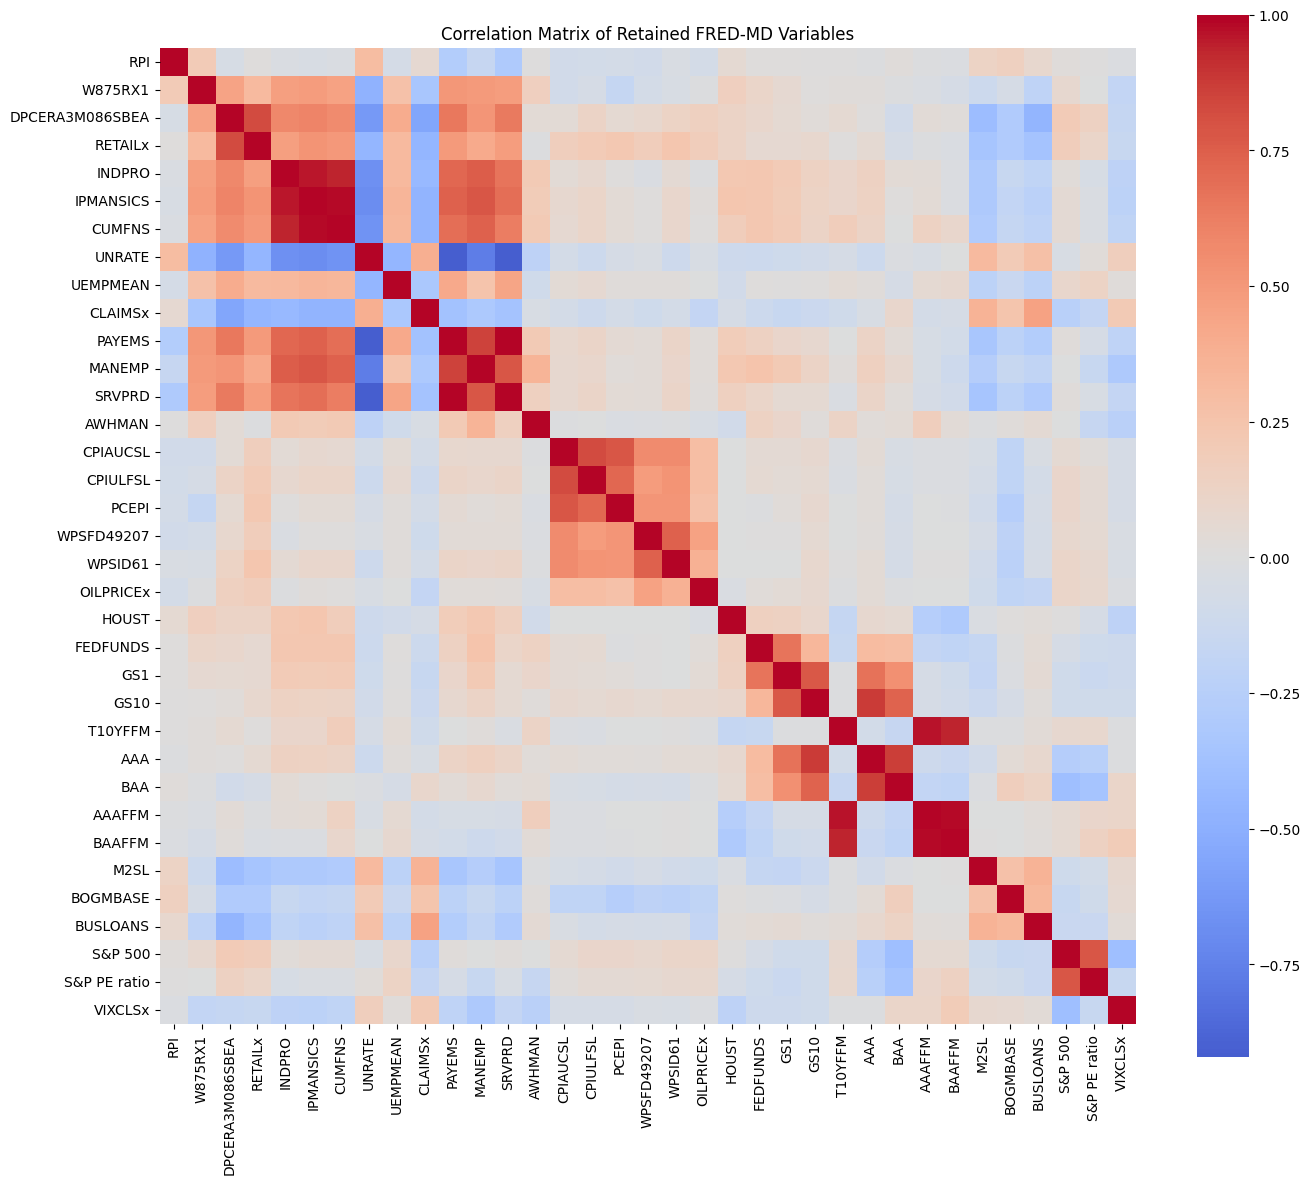

In [26]:
corr = final_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Retained FRED-MD Variables")
plt.tight_layout()
plt.show()

These correlations make sense, if needed we could remove one variable from some of the very highly correlated variables. Don't know if this is an issue yet.

### PCA Scree Plot

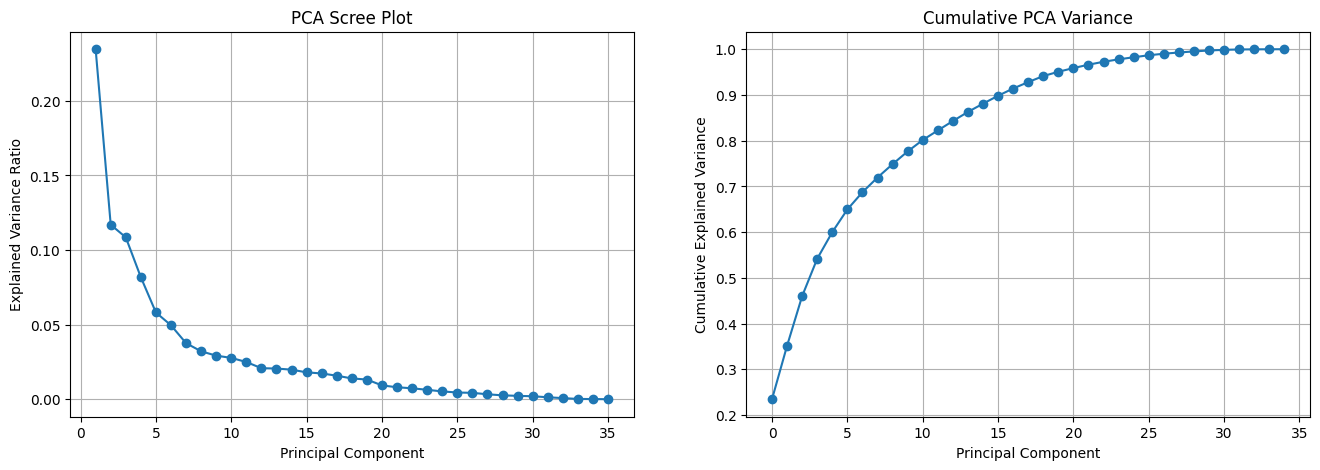

In [27]:
pca = PCA()
pca.fit(final_df.to_numpy())

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(5)
fig.set_figwidth(16)

explained = pca.explained_variance_ratio_

ax1.plot(
    range(1, len(explained)+1),
    explained,
    marker="o"
)

ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA Scree Plot")
ax1.grid(True)

ax2.plot(
    np.cumsum(explained),
    marker="o"
)

ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title("Cumulative PCA Variance")
ax2.grid(True)


plt.show()

# Price data
Getting price data of 10 industry portfolios, this is our $y(t)$ series.

Data is from the Kenneth R. French library: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

In [35]:
price_data = pd.read_csv("./datasets/10_Industry_Portfolios.csv")
price_data.set_index("Date", inplace=True)
price_data.index = pd.to_datetime(price_data.index.astype(str), format="%Y%m")
price_data = price_data.loc["1963-08-01":"2026-04-01"]
price_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 1963-08-01 to 2026-04-01
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   753 non-null    float64
 1   Durbl   753 non-null    float64
 2   Manuf   753 non-null    float64
 3   Enrgy   753 non-null    float64
 4   HiTec   753 non-null    float64
 5   Telcm   753 non-null    float64
 6   Shops   753 non-null    float64
 7   Hlth    753 non-null    float64
 8   Utils   753 non-null    float64
 9   Other   753 non-null    float64
dtypes: float64(10)
memory usage: 64.7 KB


In [36]:
# 1. Initialize a list to hold the row data
summary_data = []

# 2. Helper function to calculate the longest flatline period
def get_max_flatline(series):
    # If the series has fewer than 2 elements, flatline is 0
    if len(series) < 2:
        return 0
    return (series.diff() == 0).astype(int).groupby((series.diff() != 0).cumsum()).sum().max()

# 3. Gather metrics for each column in df
for col in price_data.columns:
    summary_data.append({
        "Column Name": col,
        "Start": price_data[col].first_valid_index(),
        "End": price_data[col].last_valid_index(),
        "N Null": price_data[col].isna().sum(),
        "N Not-Null": price_data[col].notnull().sum(),
        "N Unique": price_data[col].nunique(),
        "Max Flatline": get_max_flatline(price_data[col])
    })


# 5. Convert to a DataFrame and display without the row index numbers
summary_df = pd.DataFrame(summary_data)
summary_df


,Column Name,Start,End,N Null,N Not-Null,N Unique,Max Flatline
0,NoDur,1963-08-01,2026-04-01,0,753,588,1
1,Durbl,1963-08-01,2026-04-01,0,753,654,0
2,Manuf,1963-08-01,2026-04-01,0,753,601,0
3,Enrgy,1963-08-01,2026-04-01,0,753,625,1
4,HiTec,1963-08-01,2026-04-01,0,753,627,0
5,Telcm,1963-08-01,2026-04-01,0,753,608,1
6,Shops,1963-08-01,2026-04-01,0,753,614,1
7,Hlth,1963-08-01,2026-04-01,0,753,614,1
8,Utils,1963-08-01,2026-04-01,0,753,569,1
9,Other,1963-08-01,2026-04-01,0,753,609,1


In [37]:
price_standardised = (price_data - price_data.mean()) / price_data.std()

dates = price_standardised.index
index_names = price_standardised.columns

Y = price_standardised.to_numpy()

np.save("./datasets/Y.npy", Y)
Y.shape

(753, 10)

### $\tilde Y \in \mathbb{R}^{753 \times 10}$

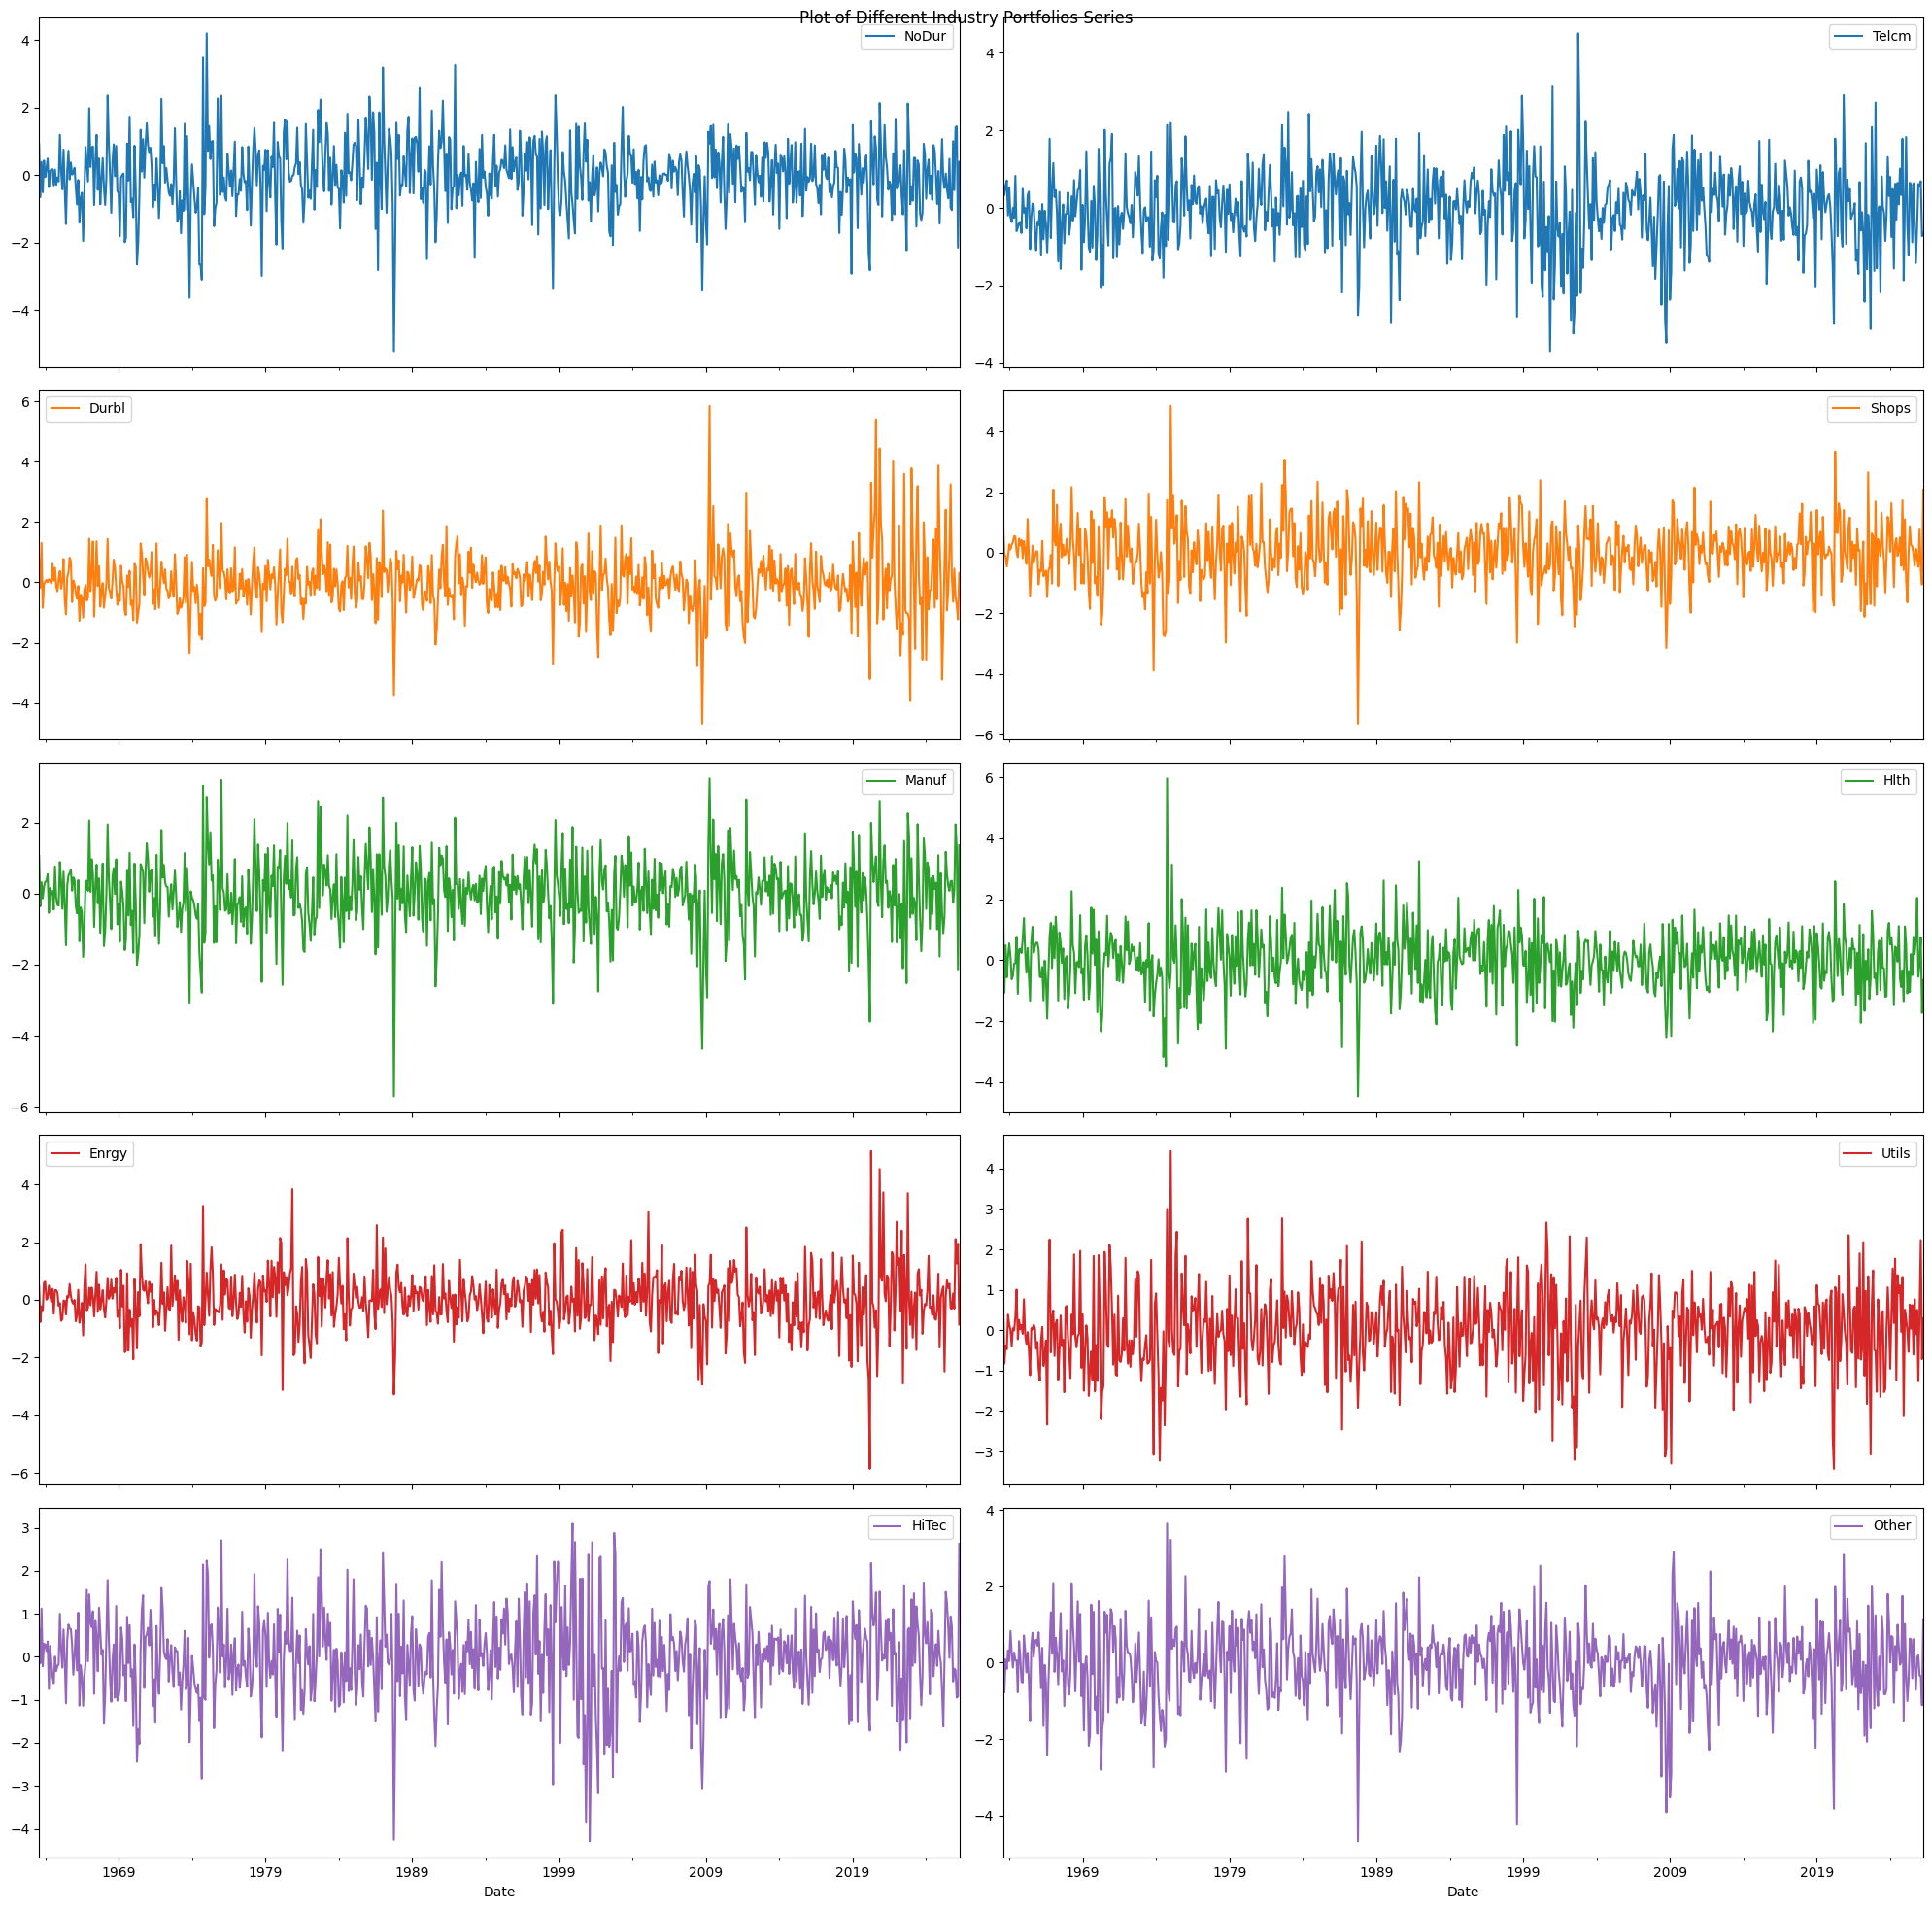

In [38]:
# 17 rows of plots, 2 columns side-by-side
num_rows = 5
fig, axes = plt.subplots(num_rows, 2, figsize=(20, 20), sharex=True)

fig.suptitle("Plot of Different Industry Portfolios Series")

# Flatten the axes array into 1D arrays for each column
col1_axes = axes[:, 0]
col2_axes = axes[:, 1]

# Plot first 17 columns in the left column
price_standardised[index_names[:5]].plot(subplots=True, ax=col1_axes[:5])
price_standardised[index_names[5:]].plot(subplots=True, ax=col2_axes[:len(index_names[5:])])


# Turn off any unused empty subplots in the grid
for ax in axes.flat:
    if not ax.has_data():
        ax.set_visible(False)

fig.tight_layout()
plt.show()

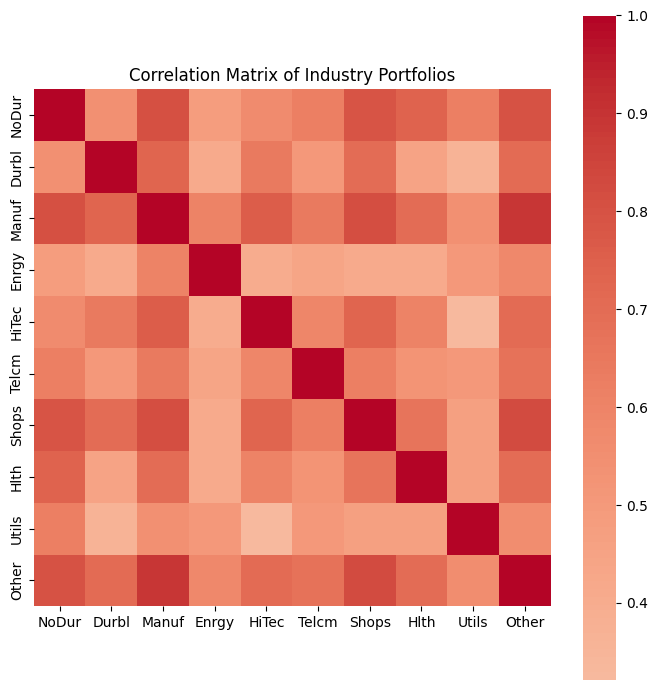

In [39]:
plt.figure(figsize=(7, 7))
sns.heatmap(
    price_standardised.corr(),
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Industry Portfolios")
plt.tight_layout()
plt.show()

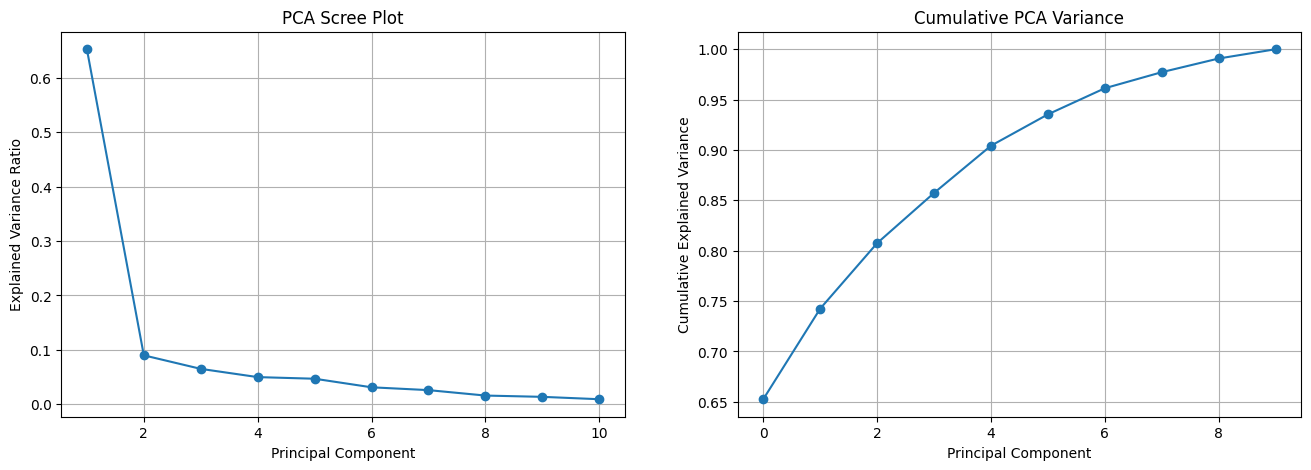

In [40]:
pca = PCA()
pca.fit(price_standardised.to_numpy())

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(5)
fig.set_figwidth(16)

explained = pca.explained_variance_ratio_

ax1.plot(
    range(1, len(explained)+1),
    explained,
    marker="o"
)

ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA Scree Plot")
ax1.grid(True)

ax2.plot(
    np.cumsum(explained),
    marker="o"
)

ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title("Cumulative PCA Variance")
ax2.grid(True)


plt.show()

# Full observation matrix

We want $z(t) = (x(t), y(t))$, so we have $\tilde Z = [\tilde X \ \tilde Y] \in \mathbb{R}^{753 \times 45}$

In [41]:
joint_df = final_df.join(price_standardised, on="sasdate")
joint_df.to_parquet("./datasets/observation_df.parquet")

Z = np.concatenate([X, Y], axis=1)
print(Z.shape)

np.save("./datasets/Z.npy", Z)

(753, 45)
